# 03 — Feature Extraction for ML

This notebook extracts **per-cycle health indicators** from the raw time-series data
and assembles them into an ML-ready feature matrix.

Features extracted per cycle:
- Discharge capacity (Ah)
- Charge capacity (Ah)  
- Coulombic efficiency (η = Q_discharge / Q_charge)
- Discharge energy (Wh)
- Mean / max temperature during discharge
- End-of-charge voltage
- End-of-discharge voltage
- Charge duration (s)
- Discharge duration (s)

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("."))

from sit_utils import SITDataset, CellData
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA_ROOT = os.path.abspath("../Data")
ds = SITDataset(DATA_ROOT)
print(ds)

SITDataset(root='c:\Users\abhirami\OneDrive - Newcastle University\Phd\PhD - Karthickumar\battery\data\SIT_Data\Batery Degradation data NYP\Data', cells=22)


## 1. Feature extraction function

In [2]:
def extract_cycle_features(cycle_df: pd.DataFrame) -> dict:
    """Extract health indicators from a single unified cycle DataFrame."""
    feats = {}
    
    # Capacity: max absolute capacity reached (already monotonic within a half-cycle)
    cap = cycle_df["capacity_Ah"]
    feats["max_capacity_Ah"] = cap.max() if len(cap) > 0 else np.nan
    
    # Energy
    if "energy_Wh" in cycle_df.columns:
        feats["max_energy_Wh"] = cycle_df["energy_Wh"].max()
    else:
        feats["max_energy_Wh"] = np.nan
    
    # Voltage extremes
    v = cycle_df["voltage_V"]
    feats["voltage_max"] = v.max()
    feats["voltage_min"] = v.min()
    feats["voltage_mean"] = v.mean()
    
    # Temperature (may have NaN if sensor not present)
    if "temperature_C" in cycle_df.columns:
        temp = cycle_df["temperature_C"].dropna()
        feats["temp_mean"] = temp.mean() if len(temp) > 0 else np.nan
        feats["temp_max"] = temp.max() if len(temp) > 0 else np.nan
    else:
        feats["temp_mean"] = np.nan
        feats["temp_max"] = np.nan
    
    # Duration
    t = cycle_df["time_s"]
    feats["duration_s"] = t.max() - t.min() if len(t) > 1 else np.nan
    
    # Current statistics
    i = cycle_df["current_A"]
    feats["current_mean"] = i.mean()
    feats["current_std"] = i.std()
    
    return feats

## 2. Extract features for one cell (demo)

In [3]:
cell = ds.get_cell("001-1")
n_cycles = cell.num_cycles
print(f"Cell 001-1: {n_cycles} cycles")

# Extract features from every 50th cycle for a quick demo
sample_indices = list(range(1, n_cycles + 1, 50))
print(f"Sampling {len(sample_indices)} cycles: {sample_indices[:5]} ...")

rows = []
for idx in sample_indices:
    try:
        cyc = cell.get_cycle(idx)
        f = extract_cycle_features(cyc)
        f["cycle"] = idx
        rows.append(f)
    except Exception as e:
        print(f"  Cycle {idx}: {e}")

feat_demo = pd.DataFrame(rows)
feat_demo = feat_demo[["cycle"] + [c for c in feat_demo.columns if c != "cycle"]]
feat_demo.round(3)

Cell 001-1: 876 cycles
Sampling 18 cycles: [1, 51, 101, 151, 201] ...
  Cycle 251: can only concatenate str (not "float") to str


,cycle,max_capacity_Ah,max_energy_Wh,voltage_max,voltage_min,voltage_mean,temp_mean,temp_max,duration_s,current_mean,current_std
0,1,52.451,160.906,3.173,2.5,3.068,36.450,45.1,3776.5,-49.997,0.002
1,51,51.387,160.392,3.461,2.5,3.121,43.149,46.4,3700.0,-49.984,0.822
2,101,50.326,156.056,3.409,2.5,3.101,35.038,40.9,3623.6,-49.984,0.830
3,151,49.788,157.183,3.453,2.5,3.157,37.639,40.1,3584.8,-49.984,0.835
4,201,49.068,154.523,3.460,2.5,3.149,37.530,40.2,3533.0,-49.983,0.841
5,301,47.496,146.803,3.417,2.5,3.091,26.413,33.9,3419.8,-49.983,0.855
6,351,46.940,145.285,3.419,2.5,3.095,26.654,32.5,3379.8,-49.983,0.860
7,401,46.779,147.276,3.469,2.5,3.148,40.976,43.5,3368.2,-49.983,0.861
8,451,46.088,144.730,3.473,2.5,3.140,38.110,41.0,3318.4,-49.982,0.868
9,501,45.447,143.042,3.512,2.5,3.147,43.508,44.6,3272.2,-49.982,0.874


## 3. Build full feature matrix for a cell

In [4]:
def build_feature_matrix(cell: CellData, every_n: int = 1) -> pd.DataFrame:
    """Extract features from all (or every n-th) cycle of a cell."""
    rows = []
    indices = range(1, cell.num_cycles + 1, every_n)
    for idx in indices:
        try:
            cyc = cell.get_cycle(idx)
            f = extract_cycle_features(cyc)
            f["cycle"] = idx
            rows.append(f)
        except Exception:
            pass
    df = pd.DataFrame(rows)
    if len(df) > 0:
        df = df[["cycle"] + [c for c in df.columns if c != "cycle"]]
    return df

In [5]:
# Full feature matrix for cell 001-1 (every 10th cycle to keep runtime manageable)
fm = build_feature_matrix(ds.get_cell("001-1"), every_n=10)
print(f"Feature matrix shape: {fm.shape}")
fm.head(10)

Feature matrix shape: (85, 11)


,cycle,max_capacity_Ah,max_energy_Wh,voltage_max,voltage_min,voltage_mean,temp_mean,temp_max,duration_s,current_mean,current_std
0,1,52.451155,160.905638,3.173290,2.500461,3.067580,36.450079,45.1,3776.50,-49.997404,0.002190
1,11,52.297173,161.425475,3.227270,2.499539,3.086540,36.804805,44.5,3765.40,-49.997378,0.002509
2,21,52.476388,163.584217,3.331411,2.500154,3.117120,42.825873,46.2,3778.30,-49.997375,0.002659
3,31,51.911518,162.001972,3.349532,2.500000,3.120619,43.686627,46.8,3737.73,-49.997381,0.002662
4,41,51.587306,160.886079,3.343996,2.500000,3.118539,42.185953,45.7,3714.38,-49.997407,0.002675
5,51,51.387480,160.392089,3.461337,2.500000,3.121189,43.149230,46.4,3700.00,-49.983799,0.821935
6,61,51.295916,160.373087,3.471488,2.500000,3.126287,45.131375,47.7,3693.40,-49.983835,0.822502
7,71,51.021983,159.415646,3.477485,2.500000,3.124357,43.941796,46.7,3673.70,-49.983800,0.824779
8,81,50.890597,159.096269,3.472256,2.500000,3.126066,44.491735,47.1,3664.20,-49.983844,0.825822
9,91,50.763217,158.390003,3.455647,2.500000,3.119971,40.537052,43.1,3655.00,-49.983739,0.826745


## 4. Visualise feature trends

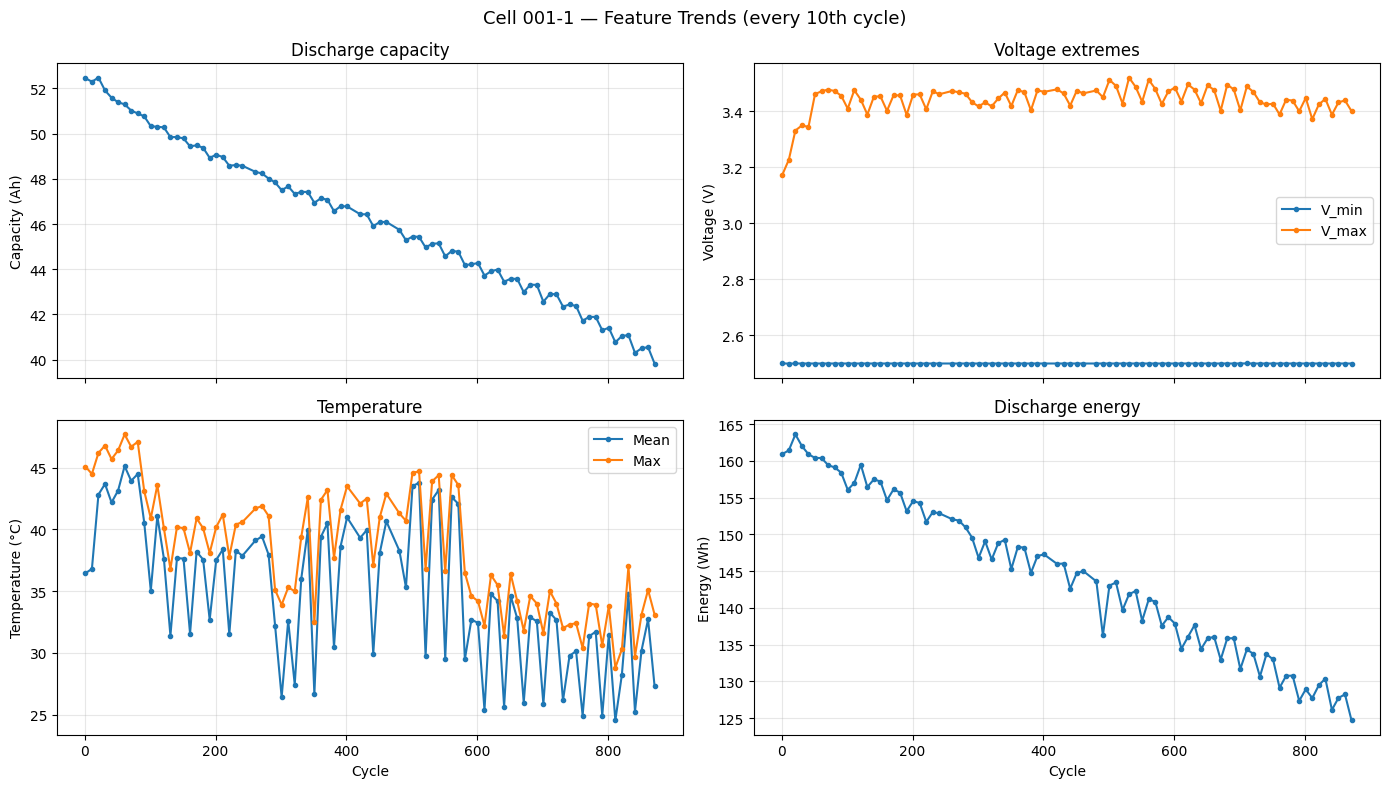

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)

axes[0, 0].plot(fm["cycle"], fm["max_capacity_Ah"], ".-")
axes[0, 0].set_ylabel("Capacity (Ah)")
axes[0, 0].set_title("Discharge capacity")

axes[0, 1].plot(fm["cycle"], fm["voltage_min"], ".-", label="V_min")
axes[0, 1].plot(fm["cycle"], fm["voltage_max"], ".-", label="V_max")
axes[0, 1].set_ylabel("Voltage (V)")
axes[0, 1].set_title("Voltage extremes")
axes[0, 1].legend()

if fm["temp_mean"].notna().any():
    axes[1, 0].plot(fm["cycle"], fm["temp_mean"], ".-", label="Mean")
    axes[1, 0].plot(fm["cycle"], fm["temp_max"], ".-", label="Max")
    axes[1, 0].legend()
axes[1, 0].set_ylabel("Temperature (°C)")
axes[1, 0].set_title("Temperature")
axes[1, 0].set_xlabel("Cycle")

axes[1, 1].plot(fm["cycle"], fm["max_energy_Wh"], ".-")
axes[1, 1].set_ylabel("Energy (Wh)")
axes[1, 1].set_title("Discharge energy")
axes[1, 1].set_xlabel("Cycle")

for ax in axes.flat:
    ax.grid(True, alpha=0.3)
fig.suptitle("Cell 001-1 — Feature Trends (every 10th cycle)", fontsize=13)
plt.tight_layout()
plt.show()

## 5. Multi-cell feature matrix

Build a combined feature matrix across all cells (sampled for speed).

In [7]:
all_rows = []
SAMPLE_EVERY = 50  # adjust for speed vs resolution

for cell_id in ds.list_cells():
    cell = ds.get_cell(cell_id)
    fm_c = build_feature_matrix(cell, every_n=SAMPLE_EVERY)
    if len(fm_c) > 0:
        fm_c.insert(0, "cell_id", cell_id)
        fm_c.insert(1, "group", cell.group)
        all_rows.append(fm_c)
    print(f"  {cell_id}: {len(fm_c)} rows")

feat_all = pd.concat(all_rows, ignore_index=True)
print(f"\nCombined feature matrix: {feat_all.shape}")
feat_all.head()

  001-1: 17 rows
  001-2: 16 rows
  001-3: 16 rows
  001-4: 18 rows
  001-5: 14 rows
  001-6: 18 rows
  001-7: 18 rows
  001-8: 16 rows
  002-1: 12 rows
  002-2: 12 rows
  002-3: 12 rows
  002-4: 12 rows
  002-5: 14 rows
  002-7: 14 rows
  003-1: 13 rows
  003-3: 14 rows
  003-5: 12 rows
  003-7: 14 rows
  101-1: 18 rows
  101-3: 14 rows
  ch5: 0 rows
  ch7: 0 rows

Combined feature matrix: (294, 13)


,cell_id,group,cycle,max_capacity_Ah,max_energy_Wh,voltage_max,voltage_min,voltage_mean,temp_mean,temp_max,duration_s,current_mean,current_std
0,001-1,G1,1,52.451155,160.905638,3.173290,2.500461,3.067580,36.450079,45.1,3776.5,-49.997404,0.002190
1,001-1,G1,51,51.387480,160.392089,3.461337,2.500000,3.121189,43.149230,46.4,3700.0,-49.983799,0.821935
2,001-1,G1,101,50.326355,156.056451,3.409357,2.500000,3.100782,35.038345,40.9,3623.6,-49.983605,0.830415
3,001-1,G1,151,49.788470,157.182819,3.453340,2.500000,3.156934,37.638985,40.1,3584.8,-49.983555,0.834921
4,001-1,G1,201,49.067934,154.522865,3.459800,2.500000,3.149109,37.530277,40.2,3533.0,-49.983297,0.841040


In [8]:
# Save to CSV for downstream ML
feat_all.to_csv("feature_matrix.csv", index=False)
print("Saved feature_matrix.csv")

Saved feature_matrix.csv


## 6. Feature correlation

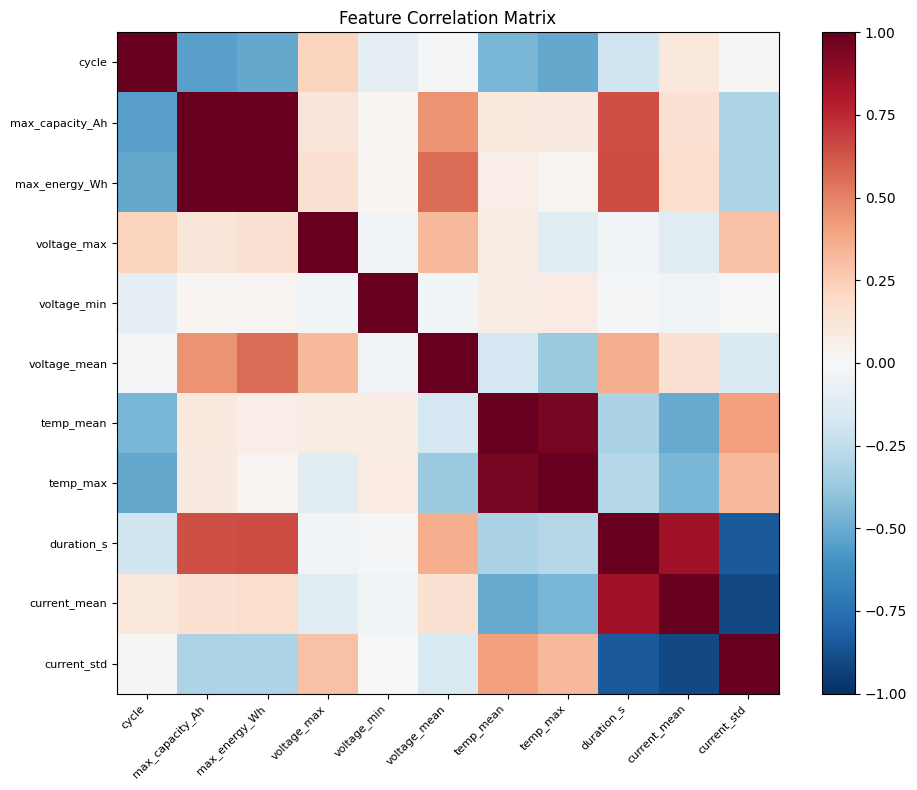

In [9]:
numeric_cols = feat_all.select_dtypes(include=[np.number]).columns.tolist()
corr = feat_all[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(numeric_cols)))
ax.set_yticks(range(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(numeric_cols, fontsize=8)
fig.colorbar(im)
ax.set_title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

---
**Next:** `04_rul_prediction.ipynb` — Use these features to train a Remaining Useful Life prediction model.